In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import regionmask

# Define file paths for different scenarios
files_historical_GFDL_ESM4 = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc'
files_SSP119_GFDL_ESM4     = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc'
files_SSP126_GFDL_ESM4     = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc'
files_SSP245_GFDL_ESM4     = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc'
files_SSP370_GFDL_ESM4     = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc'
files_SSP585_GFDL_ESM4     = 'E:/Jubjang/FWICMIP6/fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc'

# Function to load datasets from a list of file paths
def load_datasets(file_list):
    return xr.open_mfdataset(file_list, combine='by_coords', engine='netcdf4')

# Load datasets
dataset_historical_GFDL_ESM4 = load_datasets(files_historical_GFDL_ESM4)
dataset_SSP119_GFDL_ESM4     = load_datasets(files_SSP119_GFDL_ESM4)
dataset_SSP126_GFDL_ESM4     = load_datasets(files_SSP126_GFDL_ESM4)
dataset_SSP245_GFDL_ESM4     = load_datasets(files_SSP245_GFDL_ESM4)
dataset_SSP370_GFDL_ESM4     = load_datasets(files_SSP370_GFDL_ESM4)
dataset_SSP585_GFDL_ESM4     = load_datasets(files_SSP585_GFDL_ESM4)

print("Datasets successfully loaded!")
dataset_SSP585_GFDL_ESM4


Datasets successfully loaded!


<xarray.Dataset> Size: 7MB
Dimensions:  (lon: 144, lat: 72, time: 86)
Coordinates:
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * time     (time) object 688B 2015-07-01 06:00:00 ... 2100-07-01 06:00:00
Data variables:
    fwisa    (time, lat, lon) float64 7MB dask.array<chunksize=(86, 72, 144), meta=np.ndarray>
Attributes: (12/18)
    CDI:                       Climate Data Interface version 1.9.9 (https://...
    Conventions:               CF-1.6
    experiment_id:             ssp585
    table_id:                  ann
    source_id:                 GFDL-ESM4
    variant_label:             r1i1p1f1
    ...                        ...
    warning_method_init:       The FWI has been initialized by the common way...
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/exo/landclim_nobackup/yquilcaille/FWI_CMI...
    original_file_hash_codes:  ddb140eee2b50a5979c0b1fa27a066384db4659c6b03b4...
    history:                   Thu Jun 09 18:52:51 2022: cdo -O -b F64 -remap...
    CDO:                       Climate Data Operators version 1.9.9 (https://...

In [2]:
from scipy.stats import linregress
import glob

valid_combinations_MRI_ESM2_0_avg_RH = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),
    (3, 1),
    (4, 1),
    (5, 1),
    (6, 1),
    (7, 1),
    (8, 1),
    (9, 1),
    (10, 1)
]

# Generate file paths only for valid combinations
files_historical_MRI_ESM2_0_avg_RH = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_MRI_ESM2_0_avg_RH
]
file_SSP119_MRI_ESM2_0_avg_RH = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp119_r4i1p1f1_g025.nc'
files_SSP126_MRI_ESM2_0_avg_RH = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
files_SSP245_MRI_ESM2_0_avg_RH = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
files_SSP370_MRI_ESM2_0_avg_RH = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
file_SSP434_MRI_ESM2_0_avg_RH = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460_MRI_ESM2_0_avg_RH = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534_MRI_ESM2_0_avg_RH = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'

valid_combinations_ssp585_MRI_ESM2_0_avg_RH = [
    (1, 1), (1, 2),
    (2, 1),
    (3, 1),
    (4, 1),
    (5, 1)
]

# Generate file paths only for the valid combinations
files_SSP585_MRI_ESM2_0_avg_RH = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585_MRI_ESM2_0_avg_RH
]

# Function to load datasets from a list of file paths
def load_datasets_MRI_ESM2_0_avg_RH(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical_MRI_ESM2_0_avg_RH = load_datasets_MRI_ESM2_0_avg_RH(files_historical_MRI_ESM2_0_avg_RH)
dataset_SSP119_MRI_ESM2_0_avg_RH = xr.open_mfdataset(file_SSP119_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
datasets_SSP126_MRI_ESM2_0_avg_RH = load_datasets_MRI_ESM2_0_avg_RH(files_SSP126_MRI_ESM2_0_avg_RH)
datasets_SSP245_MRI_ESM2_0_avg_RH = load_datasets_MRI_ESM2_0_avg_RH(files_SSP245_MRI_ESM2_0_avg_RH)
datasets_SSP370_MRI_ESM2_0_avg_RH = load_datasets_MRI_ESM2_0_avg_RH(files_SSP370_MRI_ESM2_0_avg_RH)
dataset_SSP434_MRI_ESM2_0_avg_RH = xr.open_mfdataset(file_SSP434_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
dataset_SSP460_MRI_ESM2_0_avg_RH = xr.open_mfdataset(file_SSP460_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
dataset_SSP534_MRI_ESM2_0_avg_RH = xr.open_mfdataset(file_SSP534_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
datasets_SSP585_MRI_ESM2_0_avg_RH = load_datasets_MRI_ESM2_0_avg_RH(files_SSP585_MRI_ESM2_0_avg_RH)

print("Datasets successfully loaded for MRI-ESM2-0 (avg RH)!")

Datasets successfully loaded for MRI-ESM2-0 (avg RH)!


In [3]:
import cftime

valid_combinations_MRI_ESM2_0_min_RH = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),
    (3, 1),
    (4, 1),
    (5, 1),
    (6, 1),
    (7, 1),
    (8, 1),
    (9, 1),
    (10, 1)
]

# Generate file paths only for valid combinations
files_historical_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_MRI_ESM2_0_min_RH
]
files_SSP119_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp119_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
files_SSP126_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
# missing i3
files_SSP245_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
files_SSP370_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)
]
# file_SSP434_MRI_ESM2_0_min_RH = 'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460_MRI_ESM2_0_min_RH = 'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534_MRI_ESM2_0_min_RH = 'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'

valid_combinations_ssp585_MRI_ESM2_0_min_RH = [
    (1, 1), (1, 2),
    (2, 1),
    (3, 1),
    (4, 1),
    (5, 1)
]

# Generate file paths only for the valid combinations
files_SSP585_MRI_ESM2_0_min_RH = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585_MRI_ESM2_0_min_RH
]

# Function to load datasets from a list of file paths
def load_datasets_MRI_ESM2_0_min_RH(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_historical_MRI_ESM2_0_min_RH)
datasets_SSP119_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_SSP119_MRI_ESM2_0_min_RH)
datasets_SSP126_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_SSP126_MRI_ESM2_0_min_RH)
datasets_SSP245_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_SSP245_MRI_ESM2_0_min_RH)
datasets_SSP370_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_SSP370_MRI_ESM2_0_min_RH)
# dataset_SSP434_MRI_ESM2_0_min_RH = xr.open_mfdataset(file_SSP434_MRI_ESM2_0_min_RH, combine='by_coords', engine='netcdf4')
dataset_SSP460_MRI_ESM2_0_min_RH = xr.open_mfdataset(file_SSP460_MRI_ESM2_0_min_RH, combine='by_coords', engine='netcdf4')
dataset_SSP534_MRI_ESM2_0_min_RH = xr.open_mfdataset(file_SSP534_MRI_ESM2_0_min_RH, combine='by_coords', engine='netcdf4')
datasets_SSP585_MRI_ESM2_0_min_RH = load_datasets_MRI_ESM2_0_min_RH(files_SSP585_MRI_ESM2_0_min_RH)

print("Datasets successfully loaded! (MRI-ESM2-0, min RH)")

Datasets successfully loaded! (MRI-ESM2-0, min RH)


In [4]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon_GFDL_ESM4 = dataset_historical_GFDL_ESM4.coords['lon']
lat_GFDL_ESM4 = dataset_historical_GFDL_ESM4.coords['lat']

# Convert to radians
lon_radians_GFDL_ESM4 = np.radians(lon_GFDL_ESM4)
lat_radians_GFDL_ESM4 = np.radians(lat_GFDL_ESM4)

# Calculate the differences in longitude and latitude
delta_lon_GFDL_ESM4 = np.diff(lon_radians_GFDL_ESM4)[0]        # Assuming regular grid
delta_lat_GFDL_ESM4 = np.diff(lat_radians_GFDL_ESM4).mean()    # Mean spacing

# Calculate area for each grid cell
area_GFDL_ESM4 = np.zeros((len(lat_GFDL_ESM4), len(lon_GFDL_ESM4)))  # Full grid

for i in range(len(lat_GFDL_ESM4)):
    # Latitude bounds (extend to midpoints for full grid)
    phi_center_GFDL_ESM4 = lat_radians_GFDL_ESM4[i]
    phi1_GFDL_ESM4 = phi_center_GFDL_ESM4 - delta_lat_GFDL_ESM4 / 2
    phi2_GFDL_ESM4 = phi_center_GFDL_ESM4 + delta_lat_GFDL_ESM4 / 2

    # Calculate area for this latitude band
    area_GFDL_ESM4[i, :] = R**2 * delta_lon_GFDL_ESM4 * (np.sin(phi2_GFDL_ESM4) - np.sin(phi1_GFDL_ESM4))

# Convert to square kilometers
area_km2_GFDL_ESM4 = area_GFDL_ESM4 / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2_GFDL_ESM4)
print("Shape of area array:", area_km2_GFDL_ESM4.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [5]:
def compute_gridcell_area_km2_MRI_ESM2_0(ds, lon_name='lon', lat_name='lat'):
    lon = ds[0].coords[lon_name].values
    lat = ds[0].coords[lat_name].values

    lon_rad = np.radians(lon)
    lat_rad = np.radians(lat)

    # Regular grid spacings (radians)
    delta_lon = np.diff(lon_rad)[0]
    delta_lat = np.diff(lat_rad).mean()

    # Allocate area array (m^2)
    area = np.zeros((len(lat), len(lon)), dtype=float)

    for i in range(len(lat)):
        phi_center = lat_rad[i]
        phi1 = phi_center - delta_lat / 2
        phi2 = phi_center + delta_lat / 2
        area[i, :] = R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1))

    # Convert to km^2
    return area / 1e6

# --- Use with your historical dataset (min RH) ---
area_km2_MRI_ESM2_0_min_RH = compute_gridcell_area_km2_MRI_ESM2_0(datasets_historical_MRI_ESM2_0_min_RH)
area_km2_MRI_ESM2_0_avg_RH = compute_gridcell_area_km2_MRI_ESM2_0(datasets_historical_MRI_ESM2_0_avg_RH)

print("Area (km^2) MRI-ESM2-0 min RH shape:", area_km2_MRI_ESM2_0_min_RH.shape)
print("Area (km^2) MRI-ESM2-0 min RH shape:", area_km2_MRI_ESM2_0_avg_RH.shape)

Area (km^2) MRI-ESM2-0 min RH shape: (72, 144)
Area (km^2) MRI-ESM2-0 min RH shape: (72, 144)


In [6]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella_MRI_ESM2_0_avg_RH = xr.DataArray(
    area_km2_MRI_ESM2_0_avg_RH,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella_MRI_ESM2_0_avg_RH = xr.Dataset({"area": areacella_MRI_ESM2_0_avg_RH})

# Inspect the Dataset
print(areacella_MRI_ESM2_0_avg_RH)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [7]:
areacella_MRI_ESM2_0_min_RH = xr.DataArray(
    area_km2_MRI_ESM2_0_min_RH,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella_MRI_ESM2_0_min_RH = xr.Dataset({"area": areacella_MRI_ESM2_0_min_RH})

In [8]:
areacella_GFDL_ESM4 = xr.DataArray(
    area_km2_GFDL_ESM4,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella_GFDL_ESM4 = xr.Dataset({"area": areacella_GFDL_ESM4})

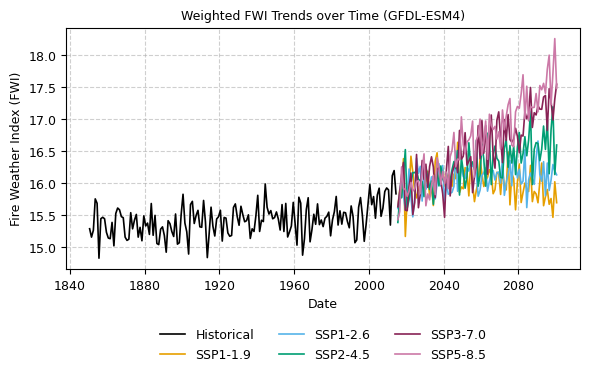

In [9]:
from datetime import datetime
def plot_fwi_trends_weighted_GFDL_ESM4(datasets_GFDL_ESM4, labels_GFDL_ESM4, title_GFDL_ESM4):
    plt.figure(figsize=(6, 4))
    
    for dataset_GFDL_ESM4, label_GFDL_ESM4 in zip(datasets_GFDL_ESM4, labels_GFDL_ESM4):
        # Convert time to datetime
        time_data_GFDL_ESM4 = [
            datetime(t.year, t.month, t.day, t.hour, t.minute, t.second)
            for t in dataset_GFDL_ESM4['time'].values
        ]
        
        # Calculate area-weighted mean FWI
        fwi_mean_GFDL_ESM4 = (
            dataset_GFDL_ESM4['fwisa']
            .weighted(areacella_GFDL_ESM4['area'])
            .mean(dim=['lat', 'lon'])
            .values
        )

        # Match color to scenario
        scenario_key_GFDL_ESM4 = None
        if "Historical" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "Historical"
        elif "SSP1-1.9" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "SSP119"
        elif "SSP1-2.6" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "SSP126"
        elif "SSP2-4.5" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "SSP245"
        elif "SSP3-7.0" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "SSP370"
        elif "SSP5-8.5" in label_GFDL_ESM4:
            scenario_key_GFDL_ESM4 = "SSP585"

        color_GFDL_ESM4 = color_blind_palette.get(scenario_key_GFDL_ESM4, "#000000")

        # Plot
        plt.plot(
            time_data_GFDL_ESM4,
            fwi_mean_GFDL_ESM4,
            label=label_GFDL_ESM4,
            color=color_GFDL_ESM4,
            linewidth=1.2
        )
    
    # Customize the plot
    plt.xlabel('Date', fontsize=9)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=9)
    plt.title(title_GFDL_ESM4, fontsize=9)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Legend below the plot
    plt.legend(
        fontsize=9,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.2),
        ncol=3,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

# Define your custom colorblind-friendly palette
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP585": "#CC79A7"
}
    
labels_all_scenarios_GFDL_ESM4 = (
    ['Historical'] +
    ['SSP1-1.9'] +
    ['SSP1-2.6'] +
    ['SSP2-4.5'] +
    ['SSP3-7.0'] +
    ['SSP5-8.5']
)

# Group datasets and labels
datasets_all_scenarios_GFDL_ESM4 = [
    dataset_historical_GFDL_ESM4,
    dataset_SSP119_GFDL_ESM4,
    dataset_SSP126_GFDL_ESM4,
    dataset_SSP245_GFDL_ESM4,
    dataset_SSP370_GFDL_ESM4,
    dataset_SSP585_GFDL_ESM4
]

# Plot FWI trends for all scenarios
plot_fwi_trends_weighted_GFDL_ESM4(
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    'Weighted FWI Trends over Time (GFDL-ESM4)'
)


In [10]:
def load_and_concatenate(file_list):
    datasets = [xr.open_dataset(file, engine='netcdf4') for file in file_list]
    concatenated = xr.concat(datasets, dim='ensemble')
    return concatenated

# Define a function to process and compute ensemble statistics
def process_ssp_data_th(file_list, lat_range, lon_range, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std

# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th_MRI_ESM2_0_avg_RH=areacella_MRI_ESM2_0_avg_RH.sel(lat=thailand_lat_range, lon=thailand_lon_range)
areacella_th_MRI_ESM2_0_min_RH=areacella_MRI_ESM2_0_min_RH.sel(lat=thailand_lat_range, lon=thailand_lon_range)


In [11]:
# Group datasets and labels
datasets_all_scenarios_MRI_ESM2_0_avg_RH = (
    datasets_historical_MRI_ESM2_0_avg_RH
    + [dataset_SSP119_MRI_ESM2_0_avg_RH]
    + datasets_SSP126_MRI_ESM2_0_avg_RH
    + datasets_SSP245_MRI_ESM2_0_avg_RH
    + datasets_SSP370_MRI_ESM2_0_avg_RH
    + [dataset_SSP434_MRI_ESM2_0_avg_RH]
    + [dataset_SSP460_MRI_ESM2_0_avg_RH]
    + [dataset_SSP534_MRI_ESM2_0_avg_RH]
    + datasets_SSP585_MRI_ESM2_0_avg_RH
)

# Thailand-weighted means/stds by scenario (avg RH)
historical_mean_th_MRI_ESM2_0_avg_RH, historical_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    files_historical_MRI_ESM2_0_avg_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp119_mean_th_MRI_ESM2_0_avg_RH, ssp119_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    [file_SSP119_MRI_ESM2_0_avg_RH], thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp126_mean_th_MRI_ESM2_0_avg_RH, ssp126_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    files_SSP126_MRI_ESM2_0_avg_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp245_mean_th_MRI_ESM2_0_avg_RH, ssp245_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    files_SSP245_MRI_ESM2_0_avg_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp370_mean_th_MRI_ESM2_0_avg_RH, ssp370_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    files_SSP370_MRI_ESM2_0_avg_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp434_mean_th_MRI_ESM2_0_avg_RH, ssp434_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    [file_SSP434_MRI_ESM2_0_avg_RH], thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp460_mean_th_MRI_ESM2_0_avg_RH, ssp460_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    [file_SSP460_MRI_ESM2_0_avg_RH], thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp534_mean_th_MRI_ESM2_0_avg_RH, ssp534_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    [file_SSP534_MRI_ESM2_0_avg_RH], thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)
ssp585_mean_th_MRI_ESM2_0_avg_RH, ssp585_std_th_MRI_ESM2_0_avg_RH = process_ssp_data_th(
    files_SSP585_MRI_ESM2_0_avg_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_avg_RH
)


In [12]:
# Function to concatenate ensemble members (safe for list or single xr object)
def concatenate_ensemble(dsets):
    """Concatenate along 'ensemble'. If a single xr object is passed, ensure an 'ensemble' dim."""
    if isinstance(dsets, (list, tuple)):
        if len(dsets) == 0:
            raise ValueError("Empty dataset list passed to concatenate_ensemble().")
        return xr.concat(dsets, dim="ensemble")
    elif isinstance(dsets, (xr.Dataset, xr.DataArray)):
        return dsets if "ensemble" in dsets.dims else dsets.expand_dims(ensemble=[0])
    else:
        raise TypeError("Expected list/tuple of xarray objects, or a single xarray object.")

# --- Concatenating historical & multi-member SSPs (already lists) ---
datasets_historical_MRI_ESM2_0_min_RH = concatenate_ensemble(datasets_historical_MRI_ESM2_0_min_RH)
datasets_SSP119_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP119_MRI_ESM2_0_min_RH)
datasets_SSP126_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP126_MRI_ESM2_0_min_RH)
datasets_SSP245_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP245_MRI_ESM2_0_min_RH)
datasets_SSP370_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP370_MRI_ESM2_0_min_RH)
datasets_SSP585_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP585_MRI_ESM2_0_min_RH)

# --- Single-member scenarios: wrap then concat ---
datasets_SSP460_MRI_ESM2_0_min_RH = concatenate_ensemble([dataset_SSP460_MRI_ESM2_0_min_RH])
datasets_SSP534_MRI_ESM2_0_min_RH = concatenate_ensemble([dataset_SSP534_MRI_ESM2_0_min_RH])


In [13]:
# Group datasets and labels
datasets_all_scenarios_MRI_ESM2_0_min_RH = [
    datasets_historical_MRI_ESM2_0_min_RH,  # Historical data
    datasets_SSP119_MRI_ESM2_0_min_RH,
    datasets_SSP126_MRI_ESM2_0_min_RH,
    datasets_SSP245_MRI_ESM2_0_min_RH,
    datasets_SSP370_MRI_ESM2_0_min_RH,
    dataset_SSP460_MRI_ESM2_0_min_RH,
    dataset_SSP534_MRI_ESM2_0_min_RH,
    datasets_SSP585_MRI_ESM2_0_min_RH
]

# Define a function to process and compute ensemble statistics
def process_ssp_data_th(ssp_data, lat_range, lon_range, area_weights):
    """
    Process a pre-concatenated dataset for the Thailand region.
    Computes ensemble mean and standard deviation.
    
    Parameters:
        ssp_data (xr.Dataset): Already concatenated dataset
        lat_range (slice): Latitude range for selection
        lon_range (slice): Longitude range for selection
        area_weights (xr.DataArray): Area weights for weighted mean
    
    Returns:
        ensemble_mean (xr.DataArray): Weighted ensemble mean
        ensemble_std (xr.DataArray): Weighted ensemble standard deviation
    """
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


# Thailand-weighted means/stds by scenario (min RH)
historical_mean_th_MRI_ESM2_0_min_RH, historical_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_historical_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp119_mean_th_MRI_ESM2_0_min_RH, ssp119_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP119_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp126_mean_th_MRI_ESM2_0_min_RH, ssp126_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP126_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp245_mean_th_MRI_ESM2_0_min_RH, ssp245_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP245_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp370_mean_th_MRI_ESM2_0_min_RH, ssp370_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP370_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp460_mean_th_MRI_ESM2_0_min_RH, ssp460_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP460_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp534_mean_th_MRI_ESM2_0_min_RH, ssp534_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP534_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)
ssp585_mean_th_MRI_ESM2_0_min_RH, ssp585_std_th_MRI_ESM2_0_min_RH = process_ssp_data_th(
    datasets_SSP585_MRI_ESM2_0_min_RH, thailand_lat_range, thailand_lon_range, areacella_th_MRI_ESM2_0_min_RH
)



In [14]:
datasets_thailand_MRI_ESM2_0_avg_RH = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range)
    for ds in datasets_all_scenarios_MRI_ESM2_0_avg_RH
]

ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH = [
    historical_mean_th_MRI_ESM2_0_avg_RH,
    ssp119_mean_th_MRI_ESM2_0_avg_RH,
    ssp126_mean_th_MRI_ESM2_0_avg_RH,
    ssp245_mean_th_MRI_ESM2_0_avg_RH,
    ssp370_mean_th_MRI_ESM2_0_avg_RH,
    ssp434_mean_th_MRI_ESM2_0_avg_RH,
    ssp460_mean_th_MRI_ESM2_0_avg_RH,
    ssp534_mean_th_MRI_ESM2_0_avg_RH,
    ssp585_mean_th_MRI_ESM2_0_avg_RH,
]

ensemble_stds_th_all_scenarios_MRI_ESM2_0_avg_RH = [
    historical_std_th_MRI_ESM2_0_avg_RH,
    ssp119_std_th_MRI_ESM2_0_avg_RH,
    ssp126_std_th_MRI_ESM2_0_avg_RH,
    ssp245_std_th_MRI_ESM2_0_avg_RH,
    ssp370_std_th_MRI_ESM2_0_avg_RH,
    ssp434_std_th_MRI_ESM2_0_avg_RH,
    ssp460_std_th_MRI_ESM2_0_avg_RH,
    ssp534_std_th_MRI_ESM2_0_avg_RH,
    ssp585_std_th_MRI_ESM2_0_avg_RH,
]


In [15]:
datasets_thailand_MRI_ESM2_0_min_RH = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios_MRI_ESM2_0_min_RH
]
# Example input (MRI-ESM2-0, min RH)
ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH = [
    historical_mean_th_MRI_ESM2_0_min_RH,
    ssp119_mean_th_MRI_ESM2_0_min_RH,
    ssp126_mean_th_MRI_ESM2_0_min_RH,
    ssp245_mean_th_MRI_ESM2_0_min_RH,
    ssp370_mean_th_MRI_ESM2_0_min_RH,
    ssp460_mean_th_MRI_ESM2_0_min_RH,
    ssp534_mean_th_MRI_ESM2_0_min_RH,
    ssp585_mean_th_MRI_ESM2_0_min_RH,
]

ensemble_stds_th_all_scenarios_MRI_ESM2_0_min_RH = [
    historical_std_th_MRI_ESM2_0_min_RH,
    ssp119_std_th_MRI_ESM2_0_min_RH,
    ssp126_std_th_MRI_ESM2_0_min_RH,
    ssp245_std_th_MRI_ESM2_0_min_RH,
    ssp370_std_th_MRI_ESM2_0_min_RH,
    ssp460_std_th_MRI_ESM2_0_min_RH,
    ssp534_std_th_MRI_ESM2_0_min_RH,
    ssp585_std_th_MRI_ESM2_0_min_RH,
]


In [16]:
color_blind_palette = {
        "Historical": "#000000",  # black
        "SSP119": "#E69F00",      # orange
        "SSP126": "#56B4E9",      # sky blue
        "SSP245": "#009E73",      # green
        "SSP370": "#882255",      # deep wine red
        "SSP434": "#E6D600",      # yellow
        "SSP460": "#D55E00",      # vermilion
        "SSP534": "#0072B2",      # navy blue
        "SSP585": "#CC79A7"       # reddish purple
    }
thailand_lat_range = (5.5, 20.5)
thailand_lon_range = (97.5, 105.5)

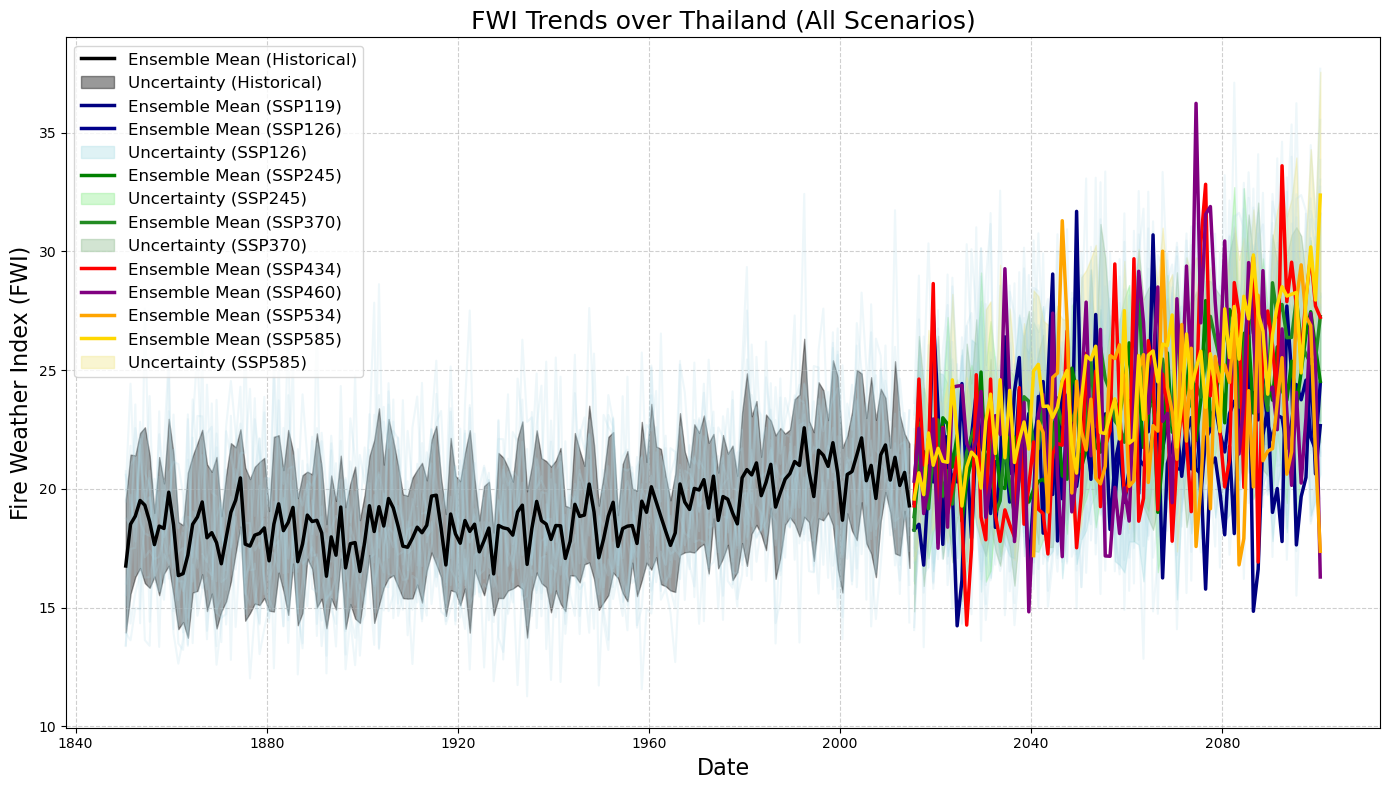

In [17]:
def plot_fwi_trends_withstd_MRI_ESM2_0_avg_RH(datasets, ensemble_means, ensemble_stds, areacella, title):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 10 datasets for clarity
        # Ensure the 'time' coordinate exists in the dataset
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Spatially average to reduce to 1D (time dimension only)
            spatial_mean = dataset['fwisa'].weighted(areacella_MRI_ESM2_0_avg_RH['area']).mean(dim=['lat', 'lon'], skipna=True)
            #spatial_mean = dataset['fwisa'].mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = [
        'black',  
        'navy',       
        'darkblue',  
        'green',      
        'forestgreen', 
        'red',        
        'purple',    
        'orange',    
        'gold',        
    ]

    # Define custom boundary colors for better visualization
    boundary_colors = [
        'black',     
        'deepskyblue', 
        'powderblue', 
        'lightgreen',  
        'darkseagreen',
        'salmon',     
        'plum',      
        'goldenrod', 
        'khaki',          
    ]

    # Define scenario labels for the legend
    scenario_labels = [
        'Historical', 
        'SSP119', 
        'SSP126', 
        'SSP245', 
        'SSP370',
        'SSP434', 
        'SSP460',
        'SSP534',
        'SSP585'
    ]

    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        # Extract DataArrays (assuming fwisa is the variable of interest)
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Ensemble mean should already be spatially averaged
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            # Skip uncertainty for SSP119
            if label == 'SSP119':
                continue
            
            # Skip uncertainty for SSP119
            if label == 'SSP434':
                continue
                
            # Skip uncertainty for SSP119
            if label == 'SSP460':
                continue
                
            # Skip uncertainty for SSP119
            if label == 'SSP534':
                continue
            
            # Calculate the uncertainty bounds (lower and upper)
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            # Plot the shaded region representing uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')  # Increase legend font size
    plt.grid(True, linestyle='--', alpha=0.6)  # Add grid with more transparency
    plt.tight_layout()
    plt.show()
# Plot the FWI trends over time for all scenarios with ensemble means and boundaries
plot_fwi_trends_withstd_MRI_ESM2_0_avg_RH(
    datasets_thailand_MRI_ESM2_0_avg_RH, 
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, 
    ensemble_stds_th_all_scenarios_MRI_ESM2_0_avg_RH, 
    areacella_MRI_ESM2_0_avg_RH,
    'FWI Trends over Thailand (All Scenarios)'
)

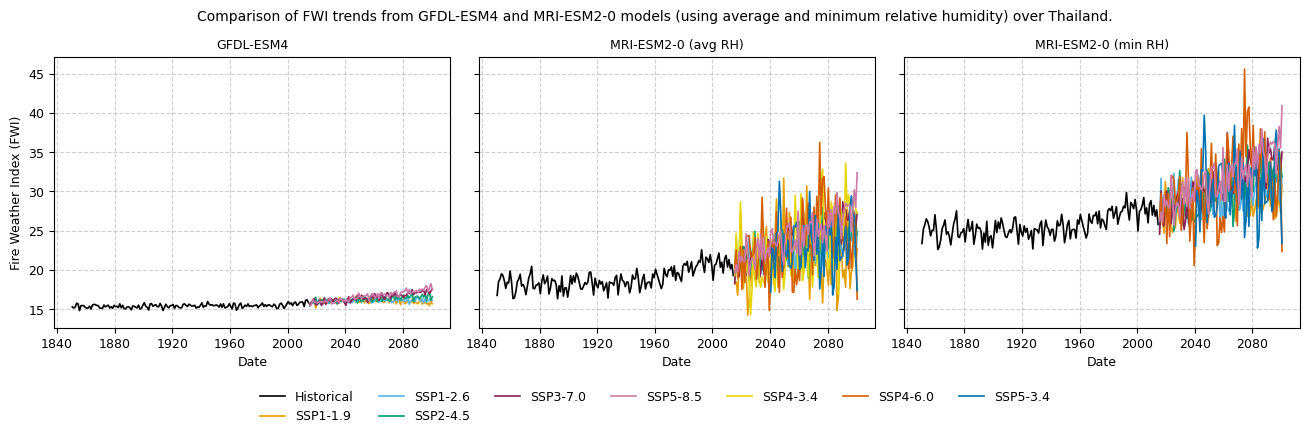

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime

# --- Color-blind friendly palette (extended) ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

def _scenario_key_from_label(label: str):
    l = label.replace(" ", "")
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in l: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in l: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in l: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in l: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in l: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in l: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in l: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in l: return "SSP585"
    return None

def _to_datetime_index(time_values):
    try:
        return pd.to_datetime(time_values)
    except Exception:
        dt_list = []
        for t in time_values:
            y = int(getattr(t, 'year', pd.Timestamp(t).year))
            m = int(getattr(t, 'month', pd.Timestamp(t).month))
            d = int(getattr(t, 'day', pd.Timestamp(t).day))
            hh = int(getattr(t, 'hour', 0))
            mm = int(getattr(t, 'minute', 0))
            ss = int(getattr(t, 'second', 0))
            dt_list.append(datetime(y, m, d, hh, mm, ss))
        return pd.to_datetime(dt_list)

def _spatial_weighted_mean_fwisa(ds_or_da, areacella=None):
    """Return 1D time series (DataArray.values) of area-weighted fwisa mean.
       If areacella is None and no lat/lon, assume already averaged."""
    da = ds_or_da['fwisa'] if isinstance(ds_or_da, xr.Dataset) else ds_or_da
    if set(['lat','lon']).issubset(da.dims) and areacella is not None:
        area = areacella['area'] if isinstance(areacella, xr.Dataset) else areacella
        da = da.weighted(area).mean(dim=['lat','lon'], skipna=True)
    if 'ensemble' in da.dims:  # tidy single line per scenario
        da = da.mean(dim='ensemble')
    return da

def _plot_panel_like_gfdl(ax, time_list, series_list, label_list):
    for t, y, lbl in zip(time_list, series_list, label_list):
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        ax.plot(t, y, label=lbl, color=color, linewidth=1.2)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(labelsize=9)

def _unique_in_order(seq):
    seen = set(); out = []
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out
# drop-in replacement
def _to_datetime_index(time_values):
    """
    Robustly convert a sequence of time values (including cftime no-leap)
    into a pandas DatetimeIndex suitable for matplotlib.
    - For cftime.* objects: build native datetimes; map Feb 29 -> Feb 28.
    - For numpy datetime64 / python datetimes: defer to pandas.
    """
    import numpy as np
    try:
        # Works for numpy datetime64, python datetime, ISO strings, etc.
        return pd.to_datetime(time_values)
    except Exception:
        out = []
        for t in np.asarray(time_values):
            # cftime path (objects with year/month/day attributes)
            if hasattr(t, "year") and hasattr(t, "month") and hasattr(t, "day"):
                y = int(t.year); m = int(t.month); d = int(t.day)
                hh = int(getattr(t, "hour", 0))
                mm = int(getattr(t, "minute", 0))
                ss = int(getattr(t, "second", 0))
                # map Feb 29 to Feb 28 for no-leap calendars
                if m == 2 and d == 29:
                    d = 28
                try:
                    out.append(datetime(y, m, d, hh, mm, ss))
                except ValueError:
                    # In case any other odd date slips through, clamp day
                    # to the last valid day of that month.
                    import calendar
                    dmax = calendar.monthrange(y, m)[1]
                    out.append(datetime(y, m, min(d, dmax), hh, mm, ss))
            else:
                # Fallback: let pandas handle scalar
                out.append(pd.to_datetime(t).to_pydatetime())
        return pd.to_datetime(out)


def plot_fwi_3panel(
    # --- REQUIRED (no defaults) ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,   # 9 labels incl. SSP4-3.4
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,   # 8 labels (no SSP4-3.4)

    # --- OPTIONAL (defaults) ---
    areacella_MRI_ESM2_0_avg_RH=None,   # pass if means still 2D (lat/lon)
    areacella_MRI_ESM2_0_min_RH=None,   # pass if means still 2D (lat/lon)
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 (avg RH)",
    title_right="MRI-ESM2-0 (min RH)"
):
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), sharey=True)
    axL, axM, axR = axes

    # ----- LEFT: GFDL (compute weighted FWI by scenario) -----
    time_L, series_L = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        t = _to_datetime_index(ts['time'].values)
        time_L.append(t); series_L.append(ts.values)
    _plot_panel_like_gfdl(axL, time_L, series_L, labels_all_scenarios_GFDL_ESM4)
    axL.set_title(title_left, fontsize=9)
    axL.set_xlabel('Date', fontsize=9)
    axL.set_ylabel('Fire Weather Index (FWI)', fontsize=9)

    # ----- MIDDLE: MRI avg RH (use ensemble mean series; includes SSP434) -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        if isinstance(mean_da, xr.Dataset):
            ts = mean_da['fwisa']
        else:
            ts = mean_da
        # area-weight if lat/lon present and weights provided
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        t = _to_datetime_index(ts['time'].values)
        time_M.append(t); series_M.append(ts.values)
    _plot_panel_like_gfdl(axM, time_M, series_M, labels_MRI_avg)
    axM.set_title(title_mid, fontsize=9)
    axM.set_xlabel('Date', fontsize=9)

    # ----- RIGHT: MRI min RH (use ensemble mean series; NO SSP434) -----
    time_R, series_R = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        if isinstance(mean_da, xr.Dataset):
            ts = mean_da['fwisa']
        else:
            ts = mean_da
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        t = _to_datetime_index(ts['time'].values)
        time_R.append(t); series_R.append(ts.values)
    _plot_panel_like_gfdl(axR, time_R, series_R, labels_MRI_min)
    axR.set_title(title_right, fontsize=9)
    axR.set_xlabel('Date', fontsize=9)

    # ----- Combined legend (union of all labels, order seen) -----
    all_labels = _unique_in_order(
        list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    )
    handles = []
    for lbl in all_labels:
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        line, = axL.plot([], [], color=color, linewidth=1.2, label=lbl)
        handles.append(line)

    fig.legend(
        handles, all_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.11),
        ncol=min(7, len(all_labels)),
        fontsize=9,
        frameon=False
    )

    fig.text(
    0.5, 1.0,   # X center, Y below the subplots
    "Comparison of FWI trends from GFDL-ESM4 and MRI-ESM2-0 models (using average and minimum relative humidity) over Thailand.",
    ha='center', va='bottom',
    fontsize=10
    )
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)
    plt.show()

# ================= EXAMPLE CALLS =================

# --- GFDL (6 scenarios) ---
# datasets_all_scenarios_GFDL_ESM4 = [dataset_historical_GFDL_ESM4, dataset_SSP119_GFDL_ESM4, ...]
# labels_all_scenarios_GFDL_ESM4    = ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP5-8.5']

# --- MRI avg RH (9 scenarios, includes SSP4-3.4) ---
labels_mri_avg = [
    'Historical', 'SSP1-1.9', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0',
    'SSP4-3.4', 'SSP4-6.0', 'SSP5-3.4', 'SSP5-8.5'
]

# --- MRI min RH (8 scenarios, NO SSP4-3.4) ---
labels_mri_min = [
    'Historical', 'SSP1-1.9', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0',
    'SSP4-6.0', 'SSP5-3.4', 'SSP5-8.5'
]

plot_fwi_3panel(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None
)


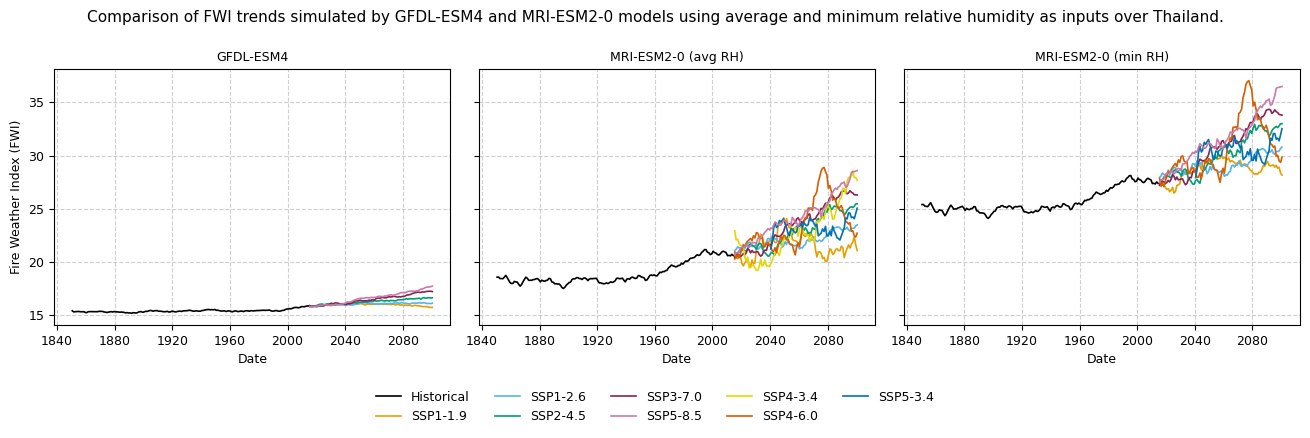

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from datetime import datetime

# --- Color-blind friendly palette (extended) ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

def _scenario_key_from_label(label: str):
    l = label.replace(" ", "")
    if "Historical" in label: return "Historical"
    if "SSP1-1.9" in label or "SSP119" in l: return "SSP119"
    if "SSP1-2.6" in label or "SSP126" in l: return "SSP126"
    if "SSP2-4.5" in label or "SSP245" in l: return "SSP245"
    if "SSP3-7.0" in label or "SSP370" in l: return "SSP370"
    if "SSP4-3.4" in label or "SSP434" in l: return "SSP434"
    if "SSP4-6.0" in label or "SSP460" in l: return "SSP460"
    if "SSP5-3.4" in label or "SSP534" in l: return "SSP534"
    if "SSP5-8.5" in label or "SSP585" in l: return "SSP585"
    return None

# Robust converter (handles cftime no-leap)
def _to_datetime_index(time_values):
    import numpy as np
    try:
        return pd.to_datetime(time_values)
    except Exception:
        out = []
        for t in np.asarray(time_values):
            if hasattr(t, "year") and hasattr(t, "month") and hasattr(t, "day"):
                y = int(t.year); m = int(t.month); d = int(t.day)
                hh = int(getattr(t, "hour", 0)); mm = int(getattr(t, "minute", 0)); ss = int(getattr(t, "second", 0))
                if m == 2 and d == 29: d = 28
                try:
                    out.append(datetime(y, m, d, hh, mm, ss))
                except ValueError:
                    import calendar
                    dmax = calendar.monthrange(y, m)[1]
                    out.append(datetime(y, m, min(d, dmax), hh, mm, ss))
            else:
                out.append(pd.to_datetime(t).to_pydatetime())
        return pd.to_datetime(out)

def _spatial_weighted_mean_fwisa(ds_or_da, areacella=None):
    da = ds_or_da['fwisa'] if isinstance(ds_or_da, xr.Dataset) else ds_or_da
    if set(['lat','lon']).issubset(da.dims) and areacella is not None:
        area = areacella['area'] if isinstance(areacella, xr.Dataset) else areacella
        da = da.weighted(area).mean(dim=['lat','lon'], skipna=True)
    if 'ensemble' in da.dims:
        da = da.mean(dim='ensemble')
    return da

# 👉 NEW: generic rolling smoother (window in time steps; e.g., years if annual)
def _apply_rolling(ts_da, window=None):
    """
    ts_da: 1D DataArray over 'time'
    window: int or None. If int>=2, applies centered rolling mean with min_periods=1.
    """
    if window is None or window < 2:
        return ts_da
    # Use pandas rolling for robust handling of irregular time indices
    t = _to_datetime_index(ts_da['time'].values)
    s = pd.Series(ts_da.values, index=t)
    sm = s.rolling(window=window, center=True, min_periods=max(1, window//2)).mean()
    # return as numpy aligned with same datetime index
    return xr.DataArray(sm.values, coords={'time': t}, dims=['time'])

def _plot_panel_like_gfdl(ax, time_list, series_list, label_list):
    for t, y, lbl in zip(time_list, series_list, label_list):
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        ax.plot(t, y, label=lbl, color=color, linewidth=1.2)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(labelsize=9)

def _unique_in_order(seq):
    seen = set(); out = []
    for x in seq:
        if x not in seen:
            seen.add(x); out.append(x)
    return out

def plot_fwi_3panel(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,   # 9 labels incl. SSP4-3.4
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,   # 8 labels (no SSP4-3.4)
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 (avg RH)",
    title_right="MRI-ESM2-0 (min RH)",
    smooth_window=None   # 👉 NEW: e.g., 5 for 5-year rolling mean
):
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), sharey=True)
    axL, axM, axR = axes

    # ----- LEFT: GFDL -----
    time_L, series_L = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)  # 👉 apply smoothing if requested
        t = _to_datetime_index(ts['time'].values)
        time_L.append(t); series_L.append(ts.values)
    _plot_panel_like_gfdl(axL, time_L, series_L, labels_all_scenarios_GFDL_ESM4)
    axL.set_title(title_left, fontsize=9)
    axL.set_xlabel('Date', fontsize=9)
    axL.set_ylabel('Fire Weather Index (FWI)', fontsize=9)

    # ----- MIDDLE: MRI avg RH -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)  # 👉 smoothing
        t = _to_datetime_index(ts['time'].values)
        time_M.append(t); series_M.append(ts.values)
    _plot_panel_like_gfdl(axM, time_M, series_M, labels_MRI_avg)
    axM.set_title(title_mid, fontsize=9)
    axM.set_xlabel('Date', fontsize=9)

    # ----- RIGHT: MRI min RH -----
    time_R, series_R = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)  # 👉 smoothing
        t = _to_datetime_index(ts['time'].values)
        time_R.append(t); series_R.append(ts.values)
    _plot_panel_like_gfdl(axR, time_R, series_R, labels_MRI_min)
    axR.set_title(title_right, fontsize=9)
    axR.set_xlabel('Date', fontsize=9)

    # ----- Combined legend -----
    all_labels = _unique_in_order(
        list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    )
    handles = []
    for lbl in all_labels:
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        line, = axL.plot([], [], color=color, linewidth=1.2, label=lbl)
        handles.append(line)

    # 👉 Put caption (top) and legend just under it
    fig.suptitle(
        "Comparison of FWI trends simulated by GFDL-ESM4 and MRI-ESM2-0 models using average and minimum relative humidity as inputs over Thailand.",
        fontsize=11, y=0.99, ha='center'
    )
    fig.legend(
        handles, all_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.11),   # legend just below the caption
        ncol=min(5, len(all_labels)),
        fontsize=9,
        frameon=False
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)  # space for caption + legend
    # --- Save figure (optional) ---
    # or e.g. "results/FWI_all_models.pdf"
    plt.savefig(
        output_path,
        dpi=300,              # high resolution for publication
        bbox_inches='tight',  # trims whitespace
        transparent=False     # set to True if you want a transparent background
    )
    plt.show()

plot_fwi_3panel(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_10yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)


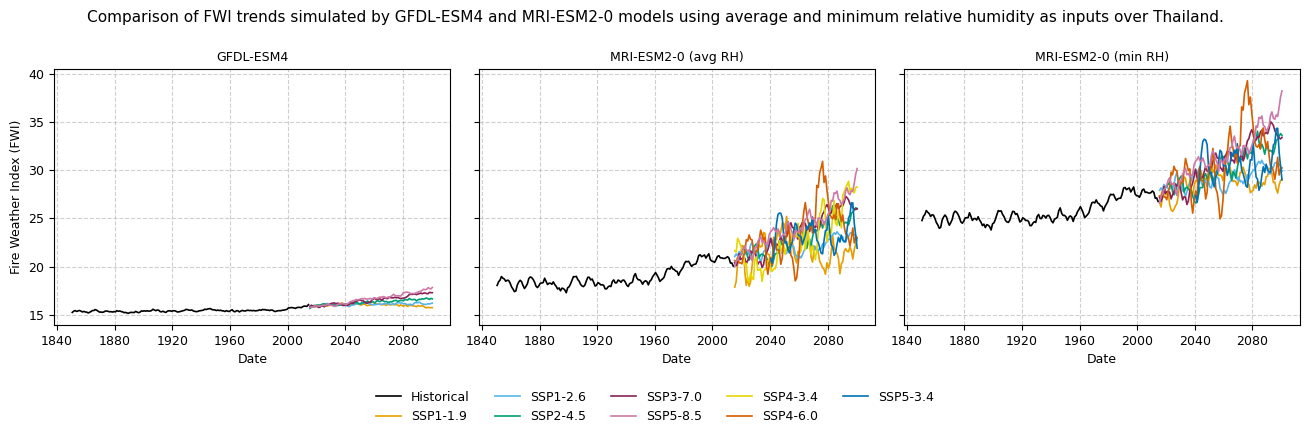

In [20]:
plot_fwi_3panel(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_5yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=5
)

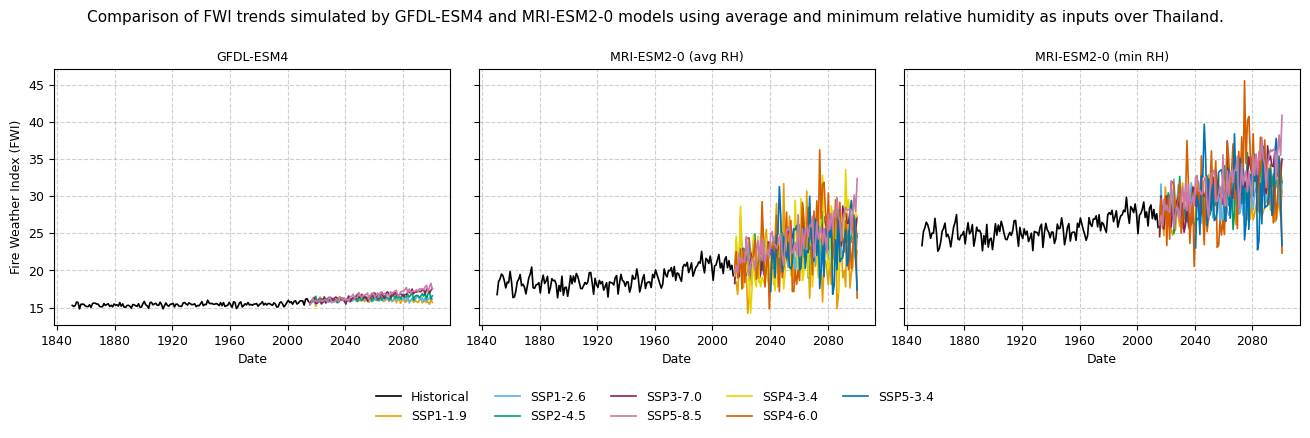

In [21]:
plot_fwi_3panel(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_1yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=1
)

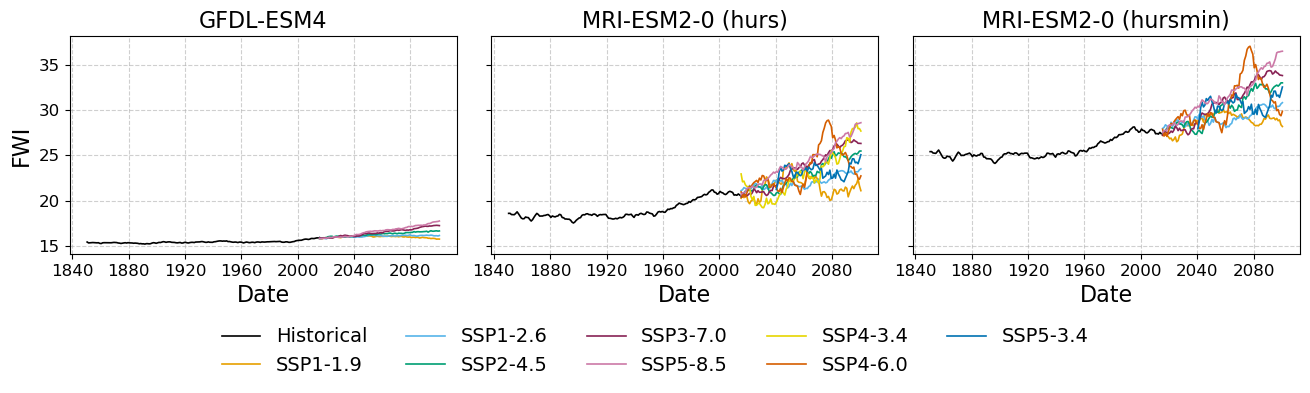

In [22]:
def _plot_panel_like_gfdl(ax, time_list, series_list, label_list):
    for t, y, lbl in zip(time_list, series_list, label_list):
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        ax.plot(t, y, label=lbl, color=color, linewidth=1.2)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(labelsize=12)

def plot_fwi_3panel_without_caption(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,   # 9 labels incl. SSP4-3.4
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,   # 8 labels (no SSP4-3.4)
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 (hurs)",
    title_right="MRI-ESM2-0 (hursmin)",
    smooth_window=None   # 👉 NEW: e.g., 5 for 5-year rolling mean
):
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.5), sharey=True)
    axL, axM, axR = axes

    # ----- LEFT: GFDL -----
    time_L, series_L = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)  # 👉 apply smoothing if requested
        t = _to_datetime_index(ts['time'].values)
        time_L.append(t); series_L.append(ts.values)
    _plot_panel_like_gfdl(axL, time_L, series_L, labels_all_scenarios_GFDL_ESM4)
    axL.set_title(title_left, fontsize=16)
    axL.set_xlabel('Date', fontsize=16)
    axL.set_ylabel('FWI', fontsize=16)

    # ----- MIDDLE: MRI avg RH -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)  # 👉 smoothing
        t = _to_datetime_index(ts['time'].values)
        time_M.append(t); series_M.append(ts.values)
    _plot_panel_like_gfdl(axM, time_M, series_M, labels_MRI_avg)
    axM.set_title(title_mid, fontsize=16)
    axM.set_xlabel('Date', fontsize=16)

    # ----- RIGHT: MRI min RH -----
    time_R, series_R = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)  # 👉 smoothing
        t = _to_datetime_index(ts['time'].values)
        time_R.append(t); series_R.append(ts.values)
    _plot_panel_like_gfdl(axR, time_R, series_R, labels_MRI_min)
    axR.set_title(title_right, fontsize=16)
    axR.set_xlabel('Date', fontsize=16)

    # ----- Combined legend -----
    all_labels = _unique_in_order(
        list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    )
    handles = []
    for lbl in all_labels:
        key = _scenario_key_from_label(lbl) or lbl
        color = color_blind_palette.get(key, "#000000")
        line, = axL.plot([], [], color=color, linewidth=1.2, label=lbl)
        handles.append(line)

    # 👉 Put caption (top) and legend just under it
    # fig.suptitle(
    #     "Comparison of FWI trends simulated by GFDL-ESM4 and MRI-ESM2-0 models using average and minimum relative humidity as inputs over Thailand.",
    #     fontsize=11, y=0.99, ha='center'
    # )
    fig.legend(
        handles, all_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.10),   # legend just below the caption
        ncol=min(5, len(all_labels)),
        fontsize=14,
        frameon=False
    )
    for ax in [axL, axM, axR]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['left'].set_visible(True)   # เอาไว้ให้มีแกน y
        ax.spines['bottom'].set_visible(True) # เอาไว้ให้มีแกน x

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.26)  # space for caption + legend
    # --- Save figure (optional) ---
    # or e.g. "results/FWI_all_models.pdf"
    plt.savefig(
        output_path,
        dpi=300,              # high resolution for publication
        bbox_inches='tight',  # trims whitespace
        transparent=False     # set to True if you want a transparent background
    )
    plt.show()

plot_fwi_3panel_without_caption(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_10yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)


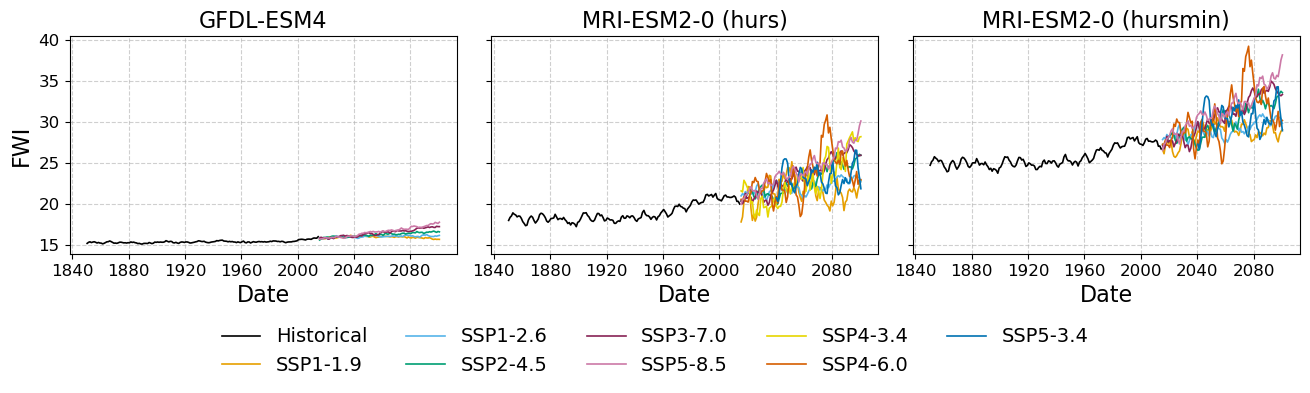

In [23]:
plot_fwi_3panel_without_caption(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_5yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=5
)


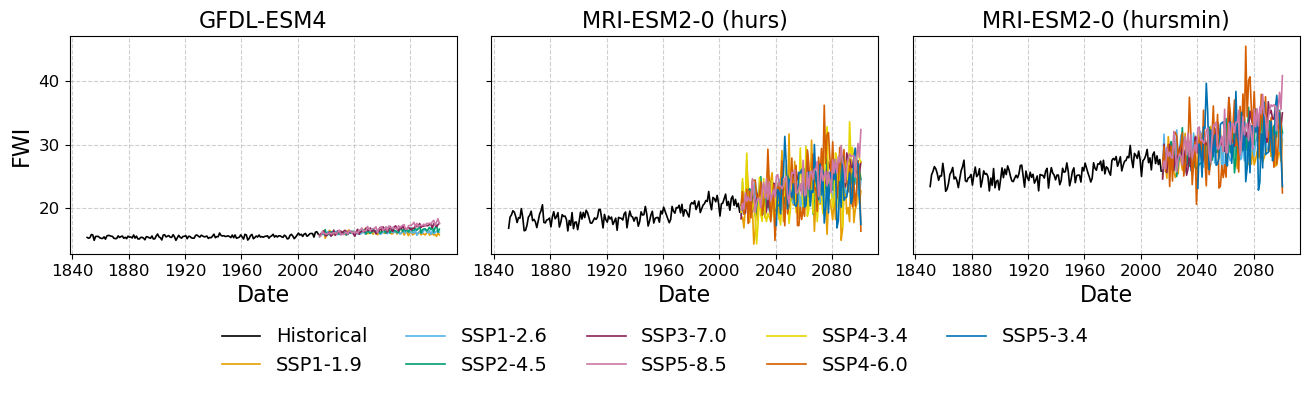

In [24]:
plot_fwi_3panel_without_caption(
    # GFDL
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,

    # MRI avg (9; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-3.4','SSP4-6.0','SSP5-3.4','SSP5-8.5'],

    # MRI min (8; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    ['Historical','SSP1-1.9','SSP1-2.6','SSP2-4.5','SSP3-7.0','SSP4-6.0','SSP5-3.4','SSP5-8.5'],
    output_path = "FWI_all_models/FWI_all_models_1yr.png",

    # optional weights (pass if your means still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=1
)


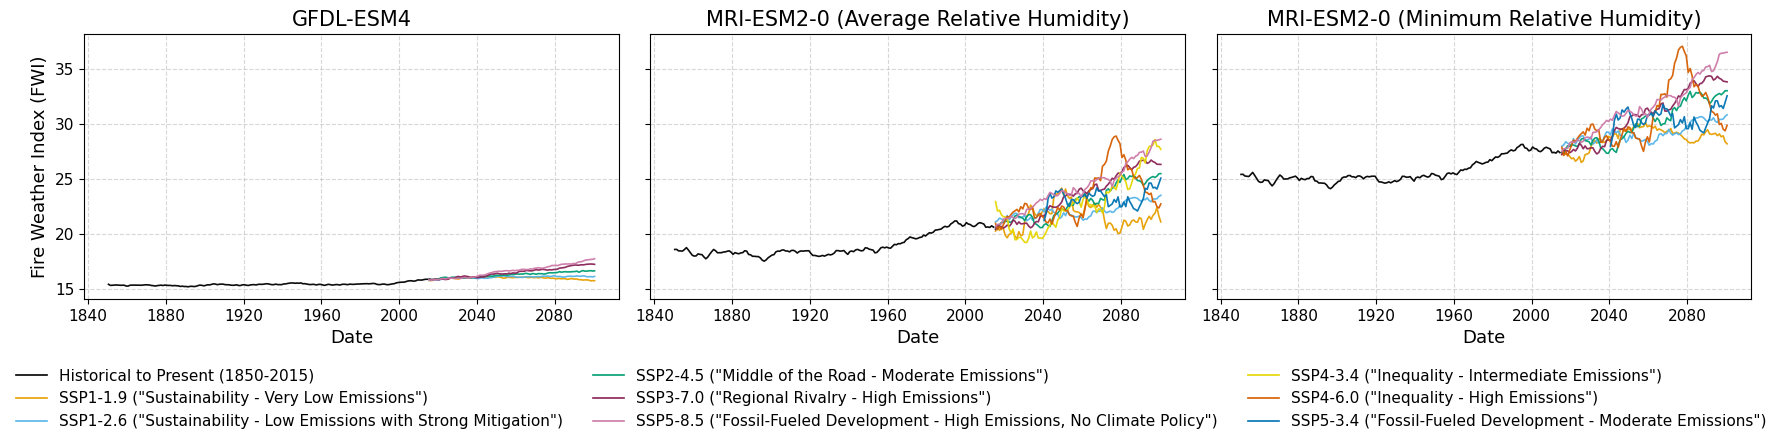

In [25]:
from typing import List
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ============================ PALETTE & LABELS ============================
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

# Long labels to use in the legend (you can reuse this for all panels)
LONG_LABELS = {
    "Historical": 'Historical to Present (1850-2015)',
    "SSP119":     'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    "SSP126":     'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    "SSP245":     'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    "SSP370":     'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    "SSP434":     'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    "SSP460":     'SSP4-6.0 ("Inequality - High Emissions")',
    "SSP534":     'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    "SSP585":     'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")',
}

# ============================== HELPERS ==================================
def _scenario_key_from_label(label: str):
    """
    Map any label (short/long) to a short key used by the palette
    """
    if not label:
        return None
    l = label.lower()
    lc = l.replace(" ", "").replace("-", "").replace(".", "")

    if "historical" in l:                 return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

def _long_label_for(label: str) -> str:
    key = _scenario_key_from_label(label)
    return LONG_LABELS.get(key, label if label is not None else "")

def _color_for_label(label: str) -> str:
    key = _scenario_key_from_label(label)
    return color_blind_palette.get(key, "#000000")

def _unique_in_order(items: List[str]) -> List[str]:
    seen = set()
    out = []
    for it in items:
        if it not in seen:
            seen.add(it)
            out.append(it)
    return out

def _to_datetime_index(time_values):
    """
    Robustly convert xarray/cftime time to pandas datetime64[ns].
    """
    if len(time_values) == 0:
        return np.array([], dtype="datetime64[ns]")
    try:
        # Handle cftime safely by stringifying
        import cftime
        if isinstance(time_values[0], cftime.DatetimeNoLeap) or isinstance(time_values[0], cftime._cftime.DatetimeNoLeap):
            return np.array([pd.Timestamp(str(t)) for t in time_values])
    except Exception:
        pass
    # Fallback to pandas
    return pd.to_datetime(time_values)

def _apply_rolling(ts: xr.DataArray, window: int | None):
    """
    Apply centered rolling mean over 'time' if requested.
    """
    if window is None or window <= 1:
        return ts
    # Ensure time is sorted
    if 'time' in ts.coords:
        ts = ts.sortby('time')
        ts = ts.rolling(time=window, center=True, min_periods=max(1, window // 2)).mean()
    return ts

def _spatial_weighted_mean_fwisa(ds_or_da, area_da: xr.DataArray):
    """
    Area-weighted spatial mean of 'fwisa' over lat/lon for a Dataset or DataArray.
    area_da must expose 'area' (DataArray) on matching lat/lon grid.
    """
    da = ds_or_da
    if isinstance(ds_or_da, xr.Dataset):
        if 'fwisa' not in ds_or_da:
            raise ValueError("Dataset must contain variable 'fwisa'.")
        da = ds_or_da['fwisa']
    if not set(['lat', 'lon']).issubset(set(da.dims)):
        return da  # already spatially averaged

    area = area_da['area'] if isinstance(area_da, xr.Dataset) else area_da
    # Align area grid to data grid if needed
    area_aligned = area.sel(lat=da.lat, lon=da.lon, method='nearest')
    return da.weighted(area_aligned).mean(dim=['lat', 'lon'])

def _plot_panel_like_gfdl(ax, time_list, series_list, labels_list):
    """
    Plot multiple time series on one axis using consistent scenario colors and long legend labels.
    The legend is NOT drawn here; it will be created once for the whole figure.
    """
    for t, y, lbl in zip(time_list, series_list, labels_list):
        long_lbl = _long_label_for(lbl)
        color = _color_for_label(lbl)
        ax.plot(t, y, label=long_lbl, linewidth=1.2, alpha=0.95, color=color)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

# =========================== MAIN 3-PANEL PLOT ===========================
def plot_fwi_3panel_without_caption(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,   # 9 labels incl. SSP4-3.4
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,   # 8 labels (no SSP4-3.4)
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 (Average Relative Humidity)",
    title_right="MRI-ESM2-0 (Minimum Relative Humidity)",
    smooth_window=None   # e.g., 10 for 10-year rolling mean
):
    """
    Draw 3 panels:
      - Left: GFDL-ESM4 scenario series
      - Middle: MRI-ESM2-0 (avg RH) ensemble-mean scenario series
      - Right: MRI-ESM2-0 (min RH) ensemble-mean scenario series

    Each line uses the color for its scenario; the legend uses your long, human-friendly labels.
    """
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 4), sharey=True)
    axL, axM, axR = axes

    # ----- LEFT: GFDL -----
    time_L, series_L = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_L.append(t); series_L.append(ts.values)
    _plot_panel_like_gfdl(axL, time_L, series_L, labels_all_scenarios_GFDL_ESM4)
    axL.set_title(title_left, fontsize=15)
    axL.set_xlabel('Date', fontsize=13)
    axL.set_ylabel('Fire Weather Index (FWI)', fontsize=13)

    # ----- MIDDLE: MRI avg RH -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        # If spatial, average with provided area
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        # If still ensemble dimension, reduce
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_M.append(t); series_M.append(ts.values)
    _plot_panel_like_gfdl(axM, time_M, series_M, labels_MRI_avg)
    axM.set_title(title_mid, fontsize=15)
    axM.set_xlabel('Date', fontsize=13)

    # ----- RIGHT: MRI min RH -----
    time_R, series_R = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_R.append(t); series_R.append(ts.values)
    _plot_panel_like_gfdl(axR, time_R, series_R, labels_MRI_min)
    axR.set_title(title_right, fontsize=15)
    axR.set_xlabel('Date', fontsize=13)

    # ----- Combined legend (uses LONG labels) -----
    # Build combined (unique) list, but convert each to the long label form.
    all_short = list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    all_long  = [_long_label_for(lbl) for lbl in all_short]
    all_long_unique = _unique_in_order(all_long)

    # Create dummy handles so legend matches colors + long labels consistently
    handles = []
    for long_lbl in all_long_unique:
        color = _color_for_label(long_lbl)
        line, = axL.plot([], [], color=color, linewidth=1.2, label=long_lbl)
        handles.append(line)

    # Legend under the top area; adjust as you like
    fig.legend(
        handles, all_long_unique,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.10),
        ncol=min(3, len(all_long_unique)),
        fontsize=11,
        frameon=False
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)  # space for legend
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches='tight',
        transparent=False
    )
    plt.show()

# ============================== EXAMPLE CALL ==============================
# Build your label lists (long-form). Ensure your datasets are in the SAME ORDER.
GFDL_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP585"],
]

MRI_avg_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP434"],  # SSP4-3.4
    LONG_LABELS["SSP460"],  # SSP4-6.0
    LONG_LABELS["SSP534"],  # SSP5-3.4
    LONG_LABELS["SSP585"],
]

MRI_min_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP460"],  # SSP4-6.0
    LONG_LABELS["SSP534"],  # SSP5-3.4
    LONG_LABELS["SSP585"],
]

# Then call (uncomment and ensure the dataset lists match orders above):
plot_fwi_3panel_without_caption(
    # GFDL (6 scenarios)
    datasets_all_scenarios_GFDL_ESM4,   # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 5-8.5]
    GFDL_long_labels,
    areacella_GFDL_ESM4,

    # MRI avg RH (9 scenarios; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,  # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 4-3.4, 4-6.0, 5-3.4, 5-8.5]
    MRI_avg_long_labels,

    # MRI min RH (8 scenarios; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,  # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 4-6.0, 5-3.4, 5-8.5]
    MRI_min_long_labels,

    output_path="FWI_all_models/FWI_all_models_10yr_long_ssp.png",

    # optional (only needed if inputs still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)


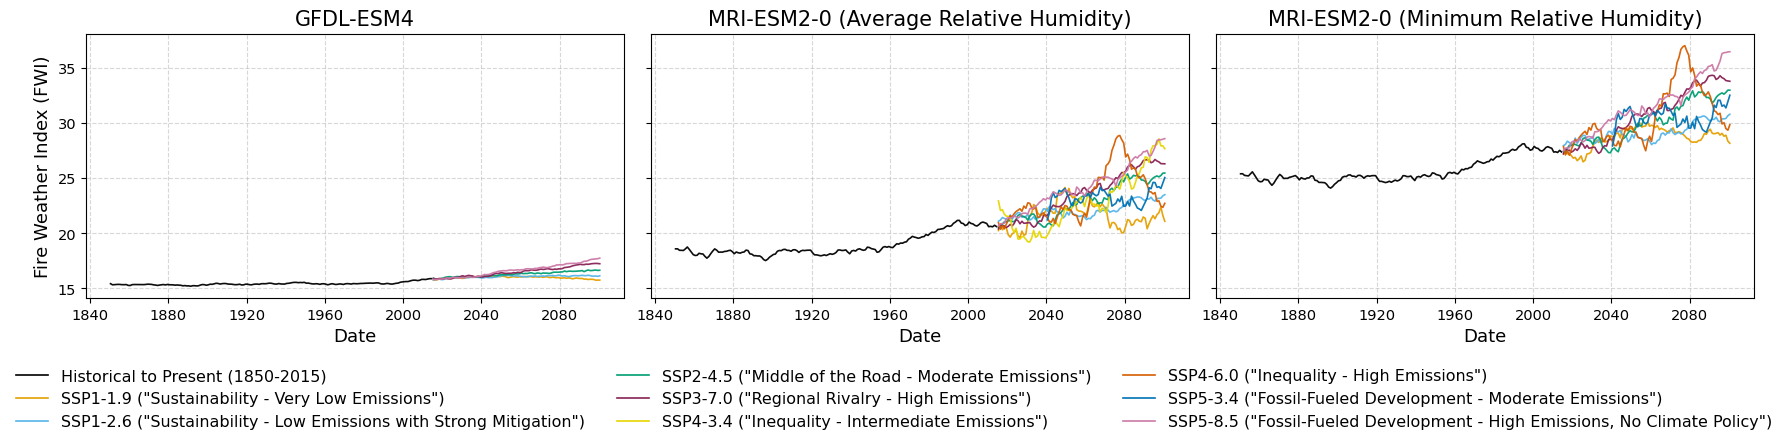

In [65]:
from typing import List
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ============================ PALETTE & LABELS ============================
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

# Long labels to use in the legend (you can reuse this for all panels)
LONG_LABELS = {
    "Historical": 'Historical to Present (1850-2015)',
    "SSP119":     'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    "SSP126":     'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    "SSP245":     'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    "SSP370":     'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    "SSP434":     'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    "SSP460":     'SSP4-6.0 ("Inequality - High Emissions")',
    "SSP534":     'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    "SSP585":     'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")',
}

# ---------------- Canonical order for plotting & legend -------------------
SCENARIO_ORDER = [
    "Historical", "SSP119", "SSP126", "SSP245", "SSP370", "SSP434", "SSP460", "SSP534", "SSP585"
]

# ============================== HELPERS ==================================
def _scenario_key_from_label(label: str):
    """
    Map any label (short/long) to a short key used by the palette
    """
    if not label:
        return None
    l = label.lower()
    lc = l.replace(" ", "").replace("-", "").replace(".", "")

    if "historical" in l:                 return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

def _long_label_for(label: str) -> str:
    key = _scenario_key_from_label(label)
    return LONG_LABELS.get(key, label if label is not None else "")

def _color_for_label(label: str) -> str:
    key = _scenario_key_from_label(label)
    return color_blind_palette.get(key, "#000000")

def _unique_in_order(items: List[str]) -> List[str]:
    seen = set()
    out = []
    for it in items:
        if it not in seen:
            seen.add(it)
            out.append(it)
    return out

def _scenario_rank(lbl: str) -> int:
    """Return index in SCENARIO_ORDER; unknowns go to the end."""
    key = _scenario_key_from_label(lbl)
    try:
        return SCENARIO_ORDER.index(key)
    except Exception:
        return 10**9

def _present_keys_in_order(labels: List[str]) -> List[str]:
    """Subset of SCENARIO_ORDER that actually appears in `labels` (canonical order)."""
    present = { _scenario_key_from_label(l) for l in labels if l is not None }
    return [k for k in SCENARIO_ORDER if k in present]

def _to_datetime_index(time_values):
    """
    Robustly convert xarray/cftime time to pandas datetime64[ns].
    """
    if len(time_values) == 0:
        return np.array([], dtype="datetime64[ns]")
    try:
        # Handle cftime safely by stringifying
        import cftime
        if isinstance(time_values[0], cftime.DatetimeNoLeap) or isinstance(time_values[0], cftime._cftime.DatetimeNoLeap):
            return np.array([pd.Timestamp(str(t)) for t in time_values])
    except Exception:
        pass
    # Fallback to pandas
    return pd.to_datetime(time_values)

def _apply_rolling(ts: xr.DataArray, window: int | None):
    """
    Apply centered rolling mean over 'time' if requested.
    """
    if window is None or window <= 1:
        return ts
    # Ensure time is sorted
    if 'time' in ts.coords:
        ts = ts.sortby('time')
        ts = ts.rolling(time=window, center=True, min_periods=max(1, window // 2)).mean()
    return ts

def _spatial_weighted_mean_fwisa(ds_or_da, area_da: xr.DataArray):
    """
    Area-weighted spatial mean of 'fwisa' over lat/lon for a Dataset or DataArray.
    area_da must expose 'area' (DataArray) on matching lat/lon grid.
    """
    da = ds_or_da
    if isinstance(ds_or_da, xr.Dataset):
        if 'fwisa' not in ds_or_da:
            raise ValueError("Dataset must contain variable 'fwisa'.")
        da = ds_or_da['fwisa']
    if not set(['lat', 'lon']).issubset(set(da.dims)):
        return da  # already spatially averaged

    area = area_da['area'] if isinstance(area_da, xr.Dataset) else area_da
    # Align area grid to data grid if needed
    area_aligned = area.sel(lat=da.lat, lon=da.lon, method='nearest')
    return da.weighted(area_aligned).mean(dim=['lat', 'lon'])

def _plot_panel_like_gfdl(ax, time_list, series_list, labels_list):
    """
    Plot multiple time series on one axis using consistent scenario colors and long legend labels.
    The lines are sorted by canonical SSP order.
    """
    triples = list(zip(time_list, series_list, labels_list))
    triples.sort(key=lambda tup: _scenario_rank(tup[2]))

    for t, y, lbl in triples:
        long_lbl = _long_label_for(lbl)
        color = _color_for_label(lbl)
        ax.plot(t, y, label=long_lbl, linewidth=1.2, alpha=0.95, color=color)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=10.5)

# =========================== MAIN 3-PANEL PLOT ===========================
def plot_fwi_3panel_without_caption(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,   # 9 labels incl. SSP4-3.4
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,   # 8 labels (no SSP4-3.4)
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 (Average Relative Humidity)",
    title_right="MRI-ESM2-0 (Minimum Relative Humidity)",
    smooth_window=None   # e.g., 10 for 10-year rolling mean
):
    """
    Draw 3 panels:
      - Left: GFDL-ESM4 scenario series
      - Middle: MRI-ESM2-0 (avg RH) ensemble-mean scenario series
      - Right: MRI-ESM2-0 (min RH) ensemble-mean scenario series

    Each line uses the color for its scenario; the legend uses long labels in canonical order.
    """
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 4), sharey=True)
    axL, axM, axR = axes

    # ----- LEFT: GFDL -----
    time_L, series_L = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_L.append(t); series_L.append(ts.values)
    _plot_panel_like_gfdl(axL, time_L, series_L, labels_all_scenarios_GFDL_ESM4)
    axL.set_title(title_left, fontsize=15)
    axL.set_xlabel('Date', fontsize=13)
    axL.set_ylabel('Fire Weather Index (FWI)', fontsize=13)

    # ----- MIDDLE: MRI avg RH -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        # If spatial, average with provided area
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        # If still ensemble dimension, reduce
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_M.append(t); series_M.append(ts.values)
    _plot_panel_like_gfdl(axM, time_M, series_M, labels_MRI_avg)
    axM.set_title(title_mid, fontsize=15)
    axM.set_xlabel('Date', fontsize=13)

    # ----- RIGHT: MRI min RH -----
    time_R, series_R = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da['fwisa'] if isinstance(mean_da, xr.Dataset) else mean_da)
        if set(['lat','lon']).issubset(getattr(ts, 'dims', [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if 'ensemble' in getattr(ts, 'dims', []):
            ts = ts.mean(dim='ensemble')
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts['time'].values)
        time_R.append(t); series_R.append(ts.values)
    _plot_panel_like_gfdl(axR, time_R, series_R, labels_MRI_min)
    axR.set_title(title_right, fontsize=15)
    axR.set_xlabel('Date', fontsize=13)

    # ----- Combined legend (canonical SSP order, long labels) -----
    all_input_labels = list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    present_keys = _present_keys_in_order(all_input_labels)  # e.g., Historical, SSP119, ...

    handles = []
    legend_texts = []
    for key in present_keys:
        long_lbl = LONG_LABELS.get(key, key)
        color = color_blind_palette.get(key, "#000000")
        line, = axL.plot([], [], color=color, linewidth=1.2, label=long_lbl)
        handles.append(line)
        legend_texts.append(long_lbl)

    fig.legend(
        handles, legend_texts,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.10),
        ncol=min(3, len(legend_texts)),
        fontsize=11.5,
        frameon=False
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24, wspace=0.05)   # space for legend
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches='tight',
        transparent=False
    )
    plt.show()

# ============================== EXAMPLE CALL ==============================
# Build your label lists (long-form). Ensure your datasets are in the SAME ORDER.
GFDL_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP585"],
]

MRI_avg_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP434"],  # SSP4-3.4
    LONG_LABELS["SSP460"],  # SSP4-6.0
    LONG_LABELS["SSP534"],  # SSP5-3.4
    LONG_LABELS["SSP585"],
]

MRI_min_long_labels = [
    LONG_LABELS["Historical"],
    LONG_LABELS["SSP119"],
    LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],
    LONG_LABELS["SSP370"],
    LONG_LABELS["SSP460"],  # SSP4-6.0
    LONG_LABELS["SSP534"],  # SSP5-3.4
    LONG_LABELS["SSP585"],
]

# Then call (uncomment and ensure the dataset lists match orders above):
plot_fwi_3panel_without_caption(
    # GFDL (6 scenarios)
    datasets_all_scenarios_GFDL_ESM4,   # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 5-8.5]
    GFDL_long_labels,
    areacella_GFDL_ESM4,

    # MRI avg RH (9 scenarios; includes SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,  # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 4-3.4, 4-6.0, 5-3.4, 5-8.5]
    MRI_avg_long_labels,

    # MRI min RH (8 scenarios; no SSP4-3.4)
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,  # [Hist, 1-1.9, 1-2.6, 2-4.5, 3-7.0, 4-6.0, 5-3.4, 5-8.5]
    MRI_min_long_labels,

    output_path="FWI_all_models/FWI_all_models_10yr_long_ssp.png",

    # optional (only needed if inputs still have lat/lon)
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)


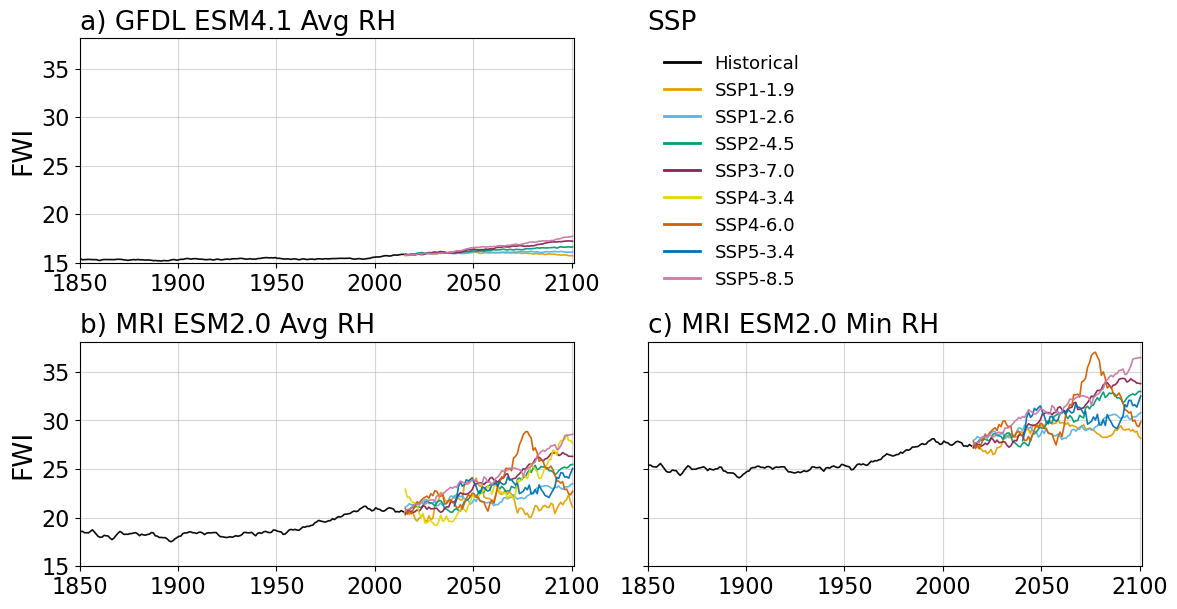

In [71]:
def _plot_panel_like_gfdl(ax, time_list, series_list, labels_list):
    """
    Plot multiple time series on one axis using consistent scenario colors and long legend labels.
    The lines are sorted by canonical SSP order.
    """
    triples = list(zip(time_list, series_list, labels_list))
    triples.sort(key=lambda tup: _scenario_rank(tup[2]))

    for t, y, lbl in triples:
        long_lbl = _long_label_for(lbl)
        color = _color_for_label(lbl)
        ax.plot(t, y, label=long_lbl, linewidth=1.2, alpha=0.95, color=color)
    ax.grid(True, alpha=0.5)
    ax.tick_params(labelsize=16)

def set_split_title(ax, left, right, fontsize=19):
    ax.set_title(left, loc="left", fontsize=fontsize)  # left side
    ax.text(1.0, 1.02, right, transform=ax.transAxes,  # right side
            ha="right", va="bottom", fontsize=fontsize)


def plot_fwi_3panel_without_caption(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 hurs",
    title_right="MRI-ESM2-0 hursmin",
    title_ssp="SSP",
    smooth_window=None
):
    """
    2x2 layout (all square panels):
      [0,0] GFDL
      [0,1] MRI (hurs / avg RH)
      [1,0] MRI (hursmin / min RH)
      [1,1] SSP legend panel
    """
    fig, axes = plt.subplots(2, 2, figsize=(7.48, 3.3), sharey=True)
    axG   = axes[0, 0]   # top-left
    axSSP = axes[0, 1]   # top-right
    
    axMRI = axes[1, 0]   # bottom-left (Avg RH)
    axMIN = axes[1, 1]   # bottom-right (Min RH)

   
    # Make each subplot box square (not data aspect)
    # for ax in [axG, axMRI, axMIN, axSSP]:
    #     if hasattr(ax, "set_box_aspect"):
    #         ax.set_box_aspect(1)

    # ----- [0,0] GFDL -----
    time_G, series_G = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds, areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_G.append(t); series_G.append(ts.values)
    _plot_panel_like_gfdl(axG, time_G, series_G, labels_all_scenarios_GFDL_ESM4)
    set_split_title(axG, "a) GFDL ESM4.1 Avg RH", "", fontsize=19)
    # axG.set_xlabel("Date", fontsize=9)
    axG.set_ylabel("FWI", fontsize=19)

    # ----- [0,1] MRI avg RH (hurs) -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da)

        if set(["lat", "lon"]).issubset(getattr(ts, "dims", [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)

        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")

        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_M.append(t); series_M.append(ts.values)

    _plot_panel_like_gfdl(axMRI, time_M, series_M, labels_MRI_avg)
    axMRI.set_ylabel("FWI", fontsize=19)
    set_split_title(axMRI, "b) MRI ESM2.0 Avg RH", "", fontsize=19)

    # axMRI.set_xlabel("Date", fontsize=9)

    # ----- [1,0] MRI min RH (hursmin) -----
    time_N, series_N = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da)

        if set(["lat", "lon"]).issubset(getattr(ts, "dims", [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)

        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")

        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_N.append(t); series_N.append(ts.values)

    _plot_panel_like_gfdl(axMIN, time_N, series_N, labels_MRI_min)
    # MRI hursmin
    set_split_title(axMIN, "c) MRI ESM2.0 Min RH", "", fontsize=19)
    # axMIN.set_xlabel("Date", fontsize=9)
    # axMIN.set_ylabel("FWI", fontsize=9)

    # ----- [1,1] SSP panel (legend only) -----
    axSSP.set_title(title_ssp, fontsize=19, loc="left")
    axSSP.axis("off")

    all_input_labels = list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    present_keys = _present_keys_in_order(all_input_labels)

    handles = []
    legend_texts = []
    for key in present_keys:
        long_lbl = SHORT_LABELS.get(key, key)
        color = color_blind_palette.get(key, "#000000")
        line, = axSSP.plot([], [], color=color, linewidth=2.0, label=long_lbl)
        handles.append(line)
        legend_texts.append(long_lbl)

    axSSP.legend(
        handles, legend_texts,
        loc="upper left",
        frameon=False,
        fontsize=13,
        ncol=1
    )
    # ===== Force axis ranges + year-only ticks =====
    xmin = pd.Timestamp("1850-01-01")
    xmax = pd.Timestamp("2100-12-31")

    years = [1850, 1900, 1950, 2000, 2050, 2100]
    year_ticks = [pd.Timestamp(f"{y}-01-01") for y in years]

    for ax in [axG, axMRI, axMIN]:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=15)

        ax.set_xticks(year_ticks)                 # positions (datetime)
        ax.set_xticklabels([str(y) for y in years])  # labels (just year)
        # ax.set_xlabel("Year", fontsize=9)

    plt.subplots_adjust(left=0.08, right=1.5, bottom=0.1, top=1.7,
                    wspace=0.15, hspace=0.35)   # ✅ ชิดกันมาก
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    plt.show()

# Short labels for legend panel
SHORT_LABELS = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",
    "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",
    "SSP370": "SSP3-7.0",
    "SSP434": "SSP4-3.4",
    "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",
    "SSP585": "SSP5-8.5",
}

plot_fwi_3panel_without_caption(
    datasets_all_scenarios_GFDL_ESM4,
    GFDL_long_labels,
    areacella_GFDL_ESM4,

    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    MRI_avg_long_labels,

    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    MRI_min_long_labels,

    output_path="FWI_all_models/FWI_all_models_2x2_square.png",
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)


In [28]:
# # ============================================================
# # FULL WORKING CMIP6 FWI PLOT (COPY–PASTE ONCE)
# # ============================================================

# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr

# # ============================================================
# # COLOR PALETTE + LABELS
# # ============================================================

# color_blind_palette = {
#     "Historical": "#000000",
#     "SSP119": "#E69F00",
#     "SSP126": "#56B4E9",
#     "SSP245": "#009E73",
#     "SSP370": "#882255",
#     "SSP434": "#E6D600",
#     "SSP460": "#D55E00",
#     "SSP534": "#0072B2",
#     "SSP585": "#CC79A7",
# }

# SHORT_LABELS = {
#     "Historical": "Historical",
#     "SSP119": "SSP1-1.9",
#     "SSP126": "SSP1-2.6",
#     "SSP245": "SSP2-4.5",
#     "SSP370": "SSP3-7.0",
#     "SSP434": "SSP4-3.4",
#     "SSP460": "SSP4-6.0",
#     "SSP534": "SSP5-3.4",
#     "SSP585": "SSP5-8.5",
# }

# # ============================================================
# # HELPERS
# # ============================================================

# def _extract_ssp_key(lbl):
#     if lbl is None:
#         return None
#     for k in SHORT_LABELS:
#         if k in lbl:
#             return k
#     if "Historical" in lbl:
#         return "Historical"
#     return None


# def _scenario_rank(lbl):
#     ssp = _extract_ssp_key(lbl)
#     if ssp == "Historical":
#         return -1   # plot FIRST (bottom)
#     order = [k for k in SHORT_LABELS if k != "Historical"]
#     return order.index(ssp) if ssp in order else 999


# def _color_for_label(lbl):
#     return color_blind_palette.get(_extract_ssp_key(lbl), "#000000")


# def _long_label_for(lbl):
#     return SHORT_LABELS.get(_extract_ssp_key(lbl), lbl)


# def _apply_rolling(da, window):
#     if window is None:
#         return da
#     return da.rolling(time=window, center=True, min_periods=1).mean()


# def _time_to_decimal_year(time_coord):
#     vals = time_coord.values
#     if np.issubdtype(vals.dtype, np.datetime64):
#         years = vals.astype("datetime64[Y]").astype(int) + 1970
#         months = (vals.astype("datetime64[M]") - vals.astype("datetime64[Y]")).astype(int) + 1
#         return years + (months - 0.5) / 12.0
#     else:
#         years = np.array([v.year for v in vals], dtype=float)
#         months = np.array([v.month for v in vals], dtype=float)
#         return years + (months - 0.5) / 12.0


# def set_split_title(ax, left, fontsize=12):
#     ax.set_title(left, loc="left", fontsize=fontsize)


# # ============================================================
# # CORE PANEL PLOT (FIXED)
# # ============================================================

# def _plot_panel_like_gfdl(ax, time_list, mean_list, labels_list, std_list):

#     triples = list(zip(time_list, mean_list, labels_list, std_list))
#     triples.sort(key=lambda t: _scenario_rank(t[2]))

#     for t, mean, lbl, std in triples:
#         ssp = _extract_ssp_key(lbl)
#         color = _color_for_label(lbl)
#         label = _long_label_for(lbl)

#         is_hist = (ssp == "Historical")

#         # ---- STD shading (SSP only) ----
#         if (not is_hist) and std is not None and np.nanmean(std) > 0:
#             ax.fill_between(
#                 t,
#                 mean - std,
#                 mean + std,
#                 facecolor=color,
#                 edgecolor=color,
#                 alpha=0.30,      # clearly visible
#                 linewidth=0.6,
#                 zorder=3
#             )

#         # ---- Mean line ----
#         ax.plot(
#             t,
#             mean,
#             color=color,
#             linewidth=1.5,
#             linestyle="--" if is_hist else "-",
#             alpha=0.95,
#             zorder=4 if not is_hist else 2
#         )

#     ax.grid(True, alpha=0.5)
#     ax.tick_params(labelsize=9)


# # ============================================================
# # MAIN FIGURE FUNCTION
# # ============================================================

# def plot_fwi_3panel_without_caption(
#     datasets_all_scenarios_GFDL_ESM4,
#     labels_all_scenarios_GFDL_ESM4,
#     areacella_GFDL_ESM4,
#     ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
#     labels_MRI_avg,
#     ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
#     labels_MRI_min,
#     output_path,
#     smooth_window=None
# ):

#     fig, axes = plt.subplots(2, 2, figsize=(6, 7), sharey=True)
#     axG, axSSP = axes[0, 0], axes[0, 1]
#     axMRI, axMIN = axes[1, 0], axes[1, 1]

#     for ax in [axG, axMRI, axMIN, axSSP]:
#         ax.set_box_aspect(1)

#     # ================= GFDL =================
#     area_da = areacella_GFDL_ESM4["area"] if isinstance(areacella_GFDL_ESM4, xr.Dataset) else areacella_GFDL_ESM4

#     time_G, mean_G, std_G = [], [], []

#     for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
#         ts = ds["fwisa"].weighted(area_da).mean(dim=["lat", "lon"])
#         ts_mean = ts.mean("ensemble") if "ensemble" in ts.dims else ts
#         ts_std  = ts.std("ensemble")  if "ensemble" in ts.dims else None

#         ts_mean = _apply_rolling(ts_mean, smooth_window)
#         if ts_std is not None:
#             ts_std = _apply_rolling(ts_std, smooth_window)

#         time_G.append(_time_to_decimal_year(ts_mean["time"]))
#         mean_G.append(ts_mean.values)
#         std_G.append(ts_std.values if ts_std is not None else None)

#     _plot_panel_like_gfdl(axG, time_G, mean_G, labels_all_scenarios_GFDL_ESM4, std_G)
#     set_split_title(axG, "a) GFDL ESM4.1 Avg RH")
#     axG.set_ylabel("FWI")

#     # ================= MRI AVG =================
#     time_M, mean_M, std_M = [], [], []

#     for da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
#         ts = da["fwisa"] if isinstance(da, xr.Dataset) else da
#         ts_mean = ts.mean("ensemble") if "ensemble" in ts.dims else ts
#         ts_std  = ts.std("ensemble")  if "ensemble" in ts.dims else None

#         ts_mean = _apply_rolling(ts_mean, smooth_window)
#         if ts_std is not None:
#             ts_std = _apply_rolling(ts_std, smooth_window)

#         time_M.append(_time_to_decimal_year(ts_mean["time"]))
#         mean_M.append(ts_mean.values)
#         std_M.append(ts_std.values if ts_std is not None else None)

#     _plot_panel_like_gfdl(axMRI, time_M, mean_M, labels_MRI_avg, std_M)
#     set_split_title(axMRI, "b) MRI ESM2.0 Avg RH")
#     axMRI.set_ylabel("FWI")

#     # ================= MRI MIN =================
#     time_N, mean_N, std_N = [], [], []

#     for da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
#         ts = da["fwisa"] if isinstance(da, xr.Dataset) else da
#         ts_mean = ts.mean("ensemble") if "ensemble" in ts.dims else ts
#         ts_std  = ts.std("ensemble")  if "ensemble" in ts.dims else None

#         ts_mean = _apply_rolling(ts_mean, smooth_window)
#         if ts_std is not None:
#             ts_std = _apply_rolling(ts_std, smooth_window)

#         time_N.append(_time_to_decimal_year(ts_mean["time"]))
#         mean_N.append(ts_mean.values)
#         std_N.append(ts_std.values if ts_std is not None else None)

#     _plot_panel_like_gfdl(axMIN, time_N, mean_N, labels_MRI_min, std_N)
#     set_split_title(axMIN, "c) MRI ESM2.0 Min RH")

#     # ================= LEGEND =================
#     axSSP.axis("off")
#     axSSP.set_title("SSP", loc="left")

#     handles, labels = [], []
#     for key in SHORT_LABELS:
#         line, = axSSP.plot([], [], color=color_blind_palette[key], lw=2)
#         handles.append(line)
#         labels.append(SHORT_LABELS[key])

#     axSSP.legend(handles, labels, frameon=False, loc="upper left")

#     # ================= AXES =================
#     years = [1850, 1900, 1950, 2000, 2050, 2100]
#     for ax in [axG, axMRI, axMIN]:
#         ax.set_xlim(1850, 2100)
#         ax.set_ylim(bottom=15)
#         ax.set_xticks(years)
#         ax.set_xticklabels(years)

#     plt.subplots_adjust(left=0.08, right=1.15, bottom=0.08,
#                         top=1.0, wspace=0.02, hspace=0.2)

#     plt.savefig(output_path, dpi=300, bbox_inches="tight")
#     plt.show()

# plot_fwi_3panel_without_caption(
#     datasets_all_scenarios_GFDL_ESM4=datasets_all_scenarios_GFDL_ESM4,
#     labels_all_scenarios_GFDL_ESM4=GFDL_long_labels,
#     areacella_GFDL_ESM4=areacella_GFDL_ESM4,

#     ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH=
#         ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
#     labels_MRI_avg=MRI_avg_long_labels,

#     ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH=
#         ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
#     labels_MRI_min=MRI_min_long_labels,

#     output_path="FWI_all_models/FWI_all_models_2x2_square.png",
#     smooth_window=10
# )
